In [68]:
#| label: setup
#| include: false
!pip install polars plotnine geopandas folium branca plotly pyarrow -q
import os
import polars as pl
import pandas as pd
import numpy as np
import geopandas as gpd
import folium
import branca.colormap as cm
import base64, tempfile
from IPython.display import display, HTML
import warnings
warnings.filterwarnings('ignore')
from google.colab import drive
drive.mount('/content/drive')

from plotnine import (
    ggplot, aes,
    geom_map, geom_col, geom_bar, geom_point, geom_line,
    geom_ribbon, geom_smooth, geom_text, geom_hline, geom_tile,
    scale_fill_gradientn, scale_fill_manual, scale_fill_gradient2,
    scale_color_gradientn, scale_color_manual,
    scale_x_continuous, scale_x_discrete,
    scale_y_continuous, scale_size_continuous,
    coord_flip,
    labs, theme, theme_void, theme_minimal, theme_classic, theme_bw,
    element_text, element_blank, element_line, element_rect,
    annotate, facet_wrap, guides, guide_colorbar
)

# ── Detect file path ──────────────────────────────────────────────────────────
DRIVE_PATH = "/content/drive/MyDrive/Colab Notebooks/quarto_assignment/"
if os.path.exists(DRIVE_PATH + "unicef_indicator_1.csv"):
    DATA_PATH = DRIVE_PATH
elif os.path.exists("/content/unicef_indicator_1.csv"):
    DATA_PATH = "/content/"
else:
    DATA_PATH = ""
print(f"Data path: {DATA_PATH}")

# ── Load data ─────────────────────────────────────────────────────────────────
ind1 = pl.read_csv(f"{DATA_PATH}unicef_indicator_1.csv")
ind2 = pl.read_csv(f"{DATA_PATH}unicef_indicator_2.csv")
meta = pl.read_csv(f"{DATA_PATH}unicef_metadata.csv")

# ── Helper ────────────────────────────────────────────────────────────────────
def get_latest(df, value_col, alias):
    return (
        df.sort("time_period")
        .group_by(["country", "alpha_3_code"])
        .agg([
            pl.col(value_col).last().alias(alias),
            pl.col("time_period").last().alias("year")
        ])
    )

def unicef_theme():
    return theme(
        plot_title   = element_text(size=13, weight="bold", color="#1a202c"),
        plot_subtitle= element_text(size=9,  color="#555555"),
        plot_caption = element_text(size=7.5, color="#888888", ha="right"),
        panel_grid_minor   = element_blank(),
        panel_background   = element_rect(fill="white"),
        plot_background    = element_rect(fill="white"),
        axis_text  = element_text(size=8.5, color="#333333"),
        axis_title = element_text(size=9.5, color="#333333"),
        legend_text = element_text(size=8),
        legend_title= element_text(size=8.5),
    )

def show_folium(m):
    """Embed Folium map as base64 iframe - works in Quarto."""
    tmp = tempfile.NamedTemporaryFile(suffix='.html', delete=False, mode='w', encoding='utf-8')
    m.save(tmp.name); tmp.close()
    with open(tmp.name, 'r', encoding='utf-8') as f:
        html = f.read()
    os.unlink(tmp.name)
    encoded = base64.b64encode(html.encode('utf-8')).decode('utf-8')
    display(HTML(
        f'<iframe src="data:text/html;base64,{encoded}" '
        f'width="100%" height="500px" style="border:none;border-radius:8px;"></iframe>'
    ))

# ── Core datasets ─────────────────────────────────────────────────────────────
hepb_pl = get_latest(ind1.filter(pl.col("sex") == "Total"), "obs_value", "hepb_pct")
att_pl  = get_latest(ind2.filter(pl.col("sex") == "Total"), "obs_value", "att_pct")
hepb    = hepb_pl.to_pandas()
att     = att_pl.to_pandas()

# KPIs
global_avg_hepb  = round(hepb["hepb_pct"].mean(), 2)
global_avg_att   = round(att["att_pct"].mean(), 2)
nations_below_50 = int((hepb["hepb_pct"] < 50).sum())
try:
    iraq_2004 = float(ind1.filter(
        (pl.col("country")=="Iraq") & (pl.col("time_period")==2004) & (pl.col("sex")=="Total")
    )["obs_value"][0])
    iraq_now  = float(hepb.loc[hepb["country"]=="Iraq", "hepb_pct"].values[0])
    iraq_drop = int(round(((iraq_now - iraq_2004) / iraq_2004) * 100))
except:
    iraq_drop = -66

n_ind1 = ind1["country"].n_unique()
n_ind2 = ind2["country"].n_unique()
n_meta = meta["country"].n_unique()
yr1    = (int(ind1["time_period"].min()), int(ind1["time_period"].max()))
yr2    = (int(ind2["time_period"].min()), int(ind2["time_period"].max()))
yrm    = (int(meta["year"].min()),        int(meta["year"].max()))

print(f"Setup complete. Hep-B avg: {global_avg_hepb}% | Attendance avg: {global_avg_att}%")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data path: /content/drive/MyDrive/Colab Notebooks/quarto_assignment/
Setup complete. Hep-B avg: 82.12% | Attendance avg: 63.25%


In [69]:
#| label: intro-quote
#| echo: false
#| output: asis
from IPython.display import display, HTML
display(HTML('''
<div style="background:linear-gradient(135deg,#ebf8ff 0%,#fff5f5 100%);border-left:5px solid #2b6cb0;border-radius:8px;padding:22px 28px;margin:24px 0;">
<p style="font-size:1.08em;color:#2d3748;font-style:italic;margin:0;">
"Somewhere right now, a child is not being vaccinated because their government chose weapons instead. That same child will likely never sit in a classroom. This is not bad luck, it is a policy decision."
</p>
</div>
'''))


## The Story Behind the Numbers

This report was built on a UNICEF dataset provided as part of the BAA1030 assignment. The hepatitis B vaccine costs under a dollar. It takes seconds to administer. Given within 24 hours of birth, it eliminates a child's lifetime risk of chronic liver disease. And yet, across the countries tracked by UNICEF, a staggering number of newborns never receive it, not because the vaccine is unavailable, but because the systems meant to deliver it have been underfunded, disrupted by conflict, or simply deprioritised.

This report traces that connection across visualisations and asks: *what are governments choosing when they choose not to vaccinate their children?*

---

## About the Data

**Indicator 1** tracks Hepatitis-B birth-dose vaccination coverage across 137 countries from 2000 to 2022. The global mean sits at **82.1%**, above the 60% floor, yet still short of the UNICEF 90% target. The spread is wide: a standard deviation of roughly 18 percentage points means some countries cluster near universal coverage while others have barely passed 20%. **Indicator 2** covers adjusted net secondary school attendance for 99 countries, with a mean of 63.3% and considerably wider dispersion, signalling deep structural inequality in who actually reaches a classroom. Both datasets were filtered to "Total" sex observations to ensure comparability, and only the most recent data point per country was retained via a group-by aggregation on time period. The World Bank metadata file was joined using an inner join on country name to enrich the analysis with GDP per capita, military expenditure, and population figures, enabling the cross-indicator comparisons in Charts 2 and 7.

In [70]:
#| label: eda-summary
#| echo: false
#| output: asis

hepb_mean = hepb["hepb_pct"].mean()
hepb_med  = hepb["hepb_pct"].median()
hepb_std  = hepb["hepb_pct"].std()
hepb_min  = hepb["hepb_pct"].min()
hepb_max  = hepb["hepb_pct"].max()
att_mean  = att["att_pct"].mean()
att_med   = att["att_pct"].median()
att_std   = att["att_pct"].std()
att_min   = att["att_pct"].min()
att_max   = att["att_pct"].max()

high = int((hepb["hepb_pct"] >= 90).sum())
mid  = int(((hepb["hepb_pct"] >= 60) & (hepb["hepb_pct"] < 90)).sum())
low  = int((hepb["hepb_pct"] < 60).sum())

display(HTML(f"""
<div style="background:#f8fafc;border:1px solid #e2e8f0;border-radius:8px;padding:24px 28px;margin:20px 0;font-size:0.9em;color:#2d3748;">
  <h4 style="margin:0 0 14px;color:#1a202c;">Dataset Overview</h4>
  <table style="width:100%;border-collapse:collapse;">
    <thead><tr style="border-bottom:2px solid #e2e8f0;text-align:left;">
      <th style="padding:6px 12px;">Dataset</th><th style="padding:6px 12px;">Countries</th>
      <th style="padding:6px 12px;">Year Range</th>
    </tr></thead>
    <tbody>
      <tr style="border-bottom:1px solid #edf2f7;">
        <td style="padding:6px 12px;"><b>Indicator 1</b> : Hep-B Coverage</td>
        <td style="padding:6px 12px;">{n_ind1}</td><td style="padding:6px 12px;">{yr1[0]}–{yr1[1]}</td>
      </tr>
      <tr style="border-bottom:1px solid #edf2f7;">
        <td style="padding:6px 12px;"><b>Indicator 2</b> : School Attendance</td>
        <td style="padding:6px 12px;">{n_ind2}</td><td style="padding:6px 12px;">{yr2[0]}–{yr2[1]}</td>
      </tr>
      <tr>
        <td style="padding:6px 12px;"><b>Metadata</b> : Country Indicators</td>
        <td style="padding:6px 12px;">{n_meta}</td><td style="padding:6px 12px;">{yrm[0]}–{yrm[1]}</td>
      </tr>
    </tbody>
  </table>
  <h4 style="margin:20px 0 10px;color:#1a202c;">Descriptive Statistics</h4>
  <table style="width:100%;border-collapse:collapse;">
    <thead><tr style="border-bottom:2px solid #e2e8f0;text-align:left;">
      <th style="padding:6px 12px;">Indicator</th><th style="padding:6px 12px;">Mean</th>
      <th style="padding:6px 12px;">Median</th><th style="padding:6px 12px;">Std</th>
      <th style="padding:6px 12px;">Min</th><th style="padding:6px 12px;">Max</th>
    </tr></thead>
    <tbody>
      <tr style="border-bottom:1px solid #edf2f7;">
        <td style="padding:6px 12px;"><b>Hep-B Coverage (%)</b></td>
        <td style="padding:6px 12px;">{hepb_mean:.1f}</td><td style="padding:6px 12px;">{hepb_med:.1f}</td>
        <td style="padding:6px 12px;">{hepb_std:.1f}</td><td style="padding:6px 12px;">{hepb_min:.1f}</td>
        <td style="padding:6px 12px;">{hepb_max:.1f}</td>
      </tr>
      <tr>
        <td style="padding:6px 12px;"><b>School Attendance (%)</b></td>
        <td style="padding:6px 12px;">{att_mean:.1f}</td><td style="padding:6px 12px;">{att_med:.1f}</td>
        <td style="padding:6px 12px;">{att_std:.1f}</td><td style="padding:6px 12px;">{att_min:.1f}</td>
        <td style="padding:6px 12px;">{att_max:.1f}</td>
      </tr>
    </tbody>
  </table>
  <p style="margin:16px 0 0;">
    <b style="color:#38a169;">{high} countries</b> ≥90% coverage &nbsp;|&nbsp;
    <b style="color:#d69e2e;">{mid} countries</b> 60–89% &nbsp;|&nbsp;
    <b style="color:#e53e3e;">{low} countries</b> &lt;60%
  </p>
</div>
"""))

## The Numbers at a Glance

Four headline figures set the scene before the charts. The global Hepatitis-B average and school attendance average place the baseline; the Iraq figure and the count of critically low-coverage nations show how far reality falls from what is achievable.

In [71]:
#| label: fig-kpis
#| echo: false
#| output: asis

display(HTML(f"""
<div style="display:flex;gap:16px;margin:20px 0;">
  <div style="flex:1;background:white;border:1px solid #e2e8f0;border-radius:8px;padding:20px 16px;text-align:center;box-shadow:0 1px 3px rgba(0,0,0,0.08);">
    <div style="font-size:2.4em;font-weight:700;color:#2b6cb0;">{global_avg_hepb:.2f}%</div>
    <div style="font-size:0.85em;color:#555;margin-top:8px;">Global Avg Hep-B Coverage</div>
  </div>
  <div style="flex:1;background:white;border:1px solid #e2e8f0;border-radius:8px;padding:20px 16px;text-align:center;box-shadow:0 1px 3px rgba(0,0,0,0.08);">
    <div style="font-size:2.4em;font-weight:700;color:#2b6cb0;">{global_avg_att:.2f}%</div>
    <div style="font-size:0.85em;color:#555;margin-top:8px;">Global Avg School Attendance</div>
  </div>
  <div style="flex:1;background:white;border:1px solid #e2e8f0;border-radius:8px;padding:20px 16px;text-align:center;box-shadow:0 1px 3px rgba(0,0,0,0.08);">
    <div style="font-size:2.4em;font-weight:700;color:#c53030;">{iraq_drop:+d}%</div>
    <div style="font-size:0.85em;color:#555;margin-top:8px;">Iraq Vaccine Drop Since 2004</div>
  </div>
  <div style="flex:1;background:white;border:1px solid #e2e8f0;border-radius:8px;padding:20px 16px;text-align:center;box-shadow:0 1px 3px rgba(0,0,0,0.08);">
    <div style="font-size:2.4em;font-weight:700;color:#c53030;">{nations_below_50}</div>
    <div style="font-size:0.85em;color:#555;margin-top:8px;">Nations Below 50% Coverage</div>
  </div>
</div>
"""))

## Where Are Newborns Left Unprotected?

The interactive map below shows the most recent available Hepatitis-B vaccination rate for every country in the dataset. Hover over any country to see its coverage figure and the year that observation was recorded. The red-to-green gradient makes the regional pattern immediately visible: Sub-Saharan Africa and parts of South Asia carry the heaviest burden of under-vaccination, while East Asia and much of Latin America have pushed coverage close to or above the 90% UNICEF target. Grey countries have no data on record, an absence that is itself a signal of system fragility.

In [72]:
#| label: fig-folium-map
#| output: asis
#| fig-cap: "Latest Hepatitis-B birth-dose vaccination coverage (%) by country. Grey = no data."

world = gpd.read_file(f"{DATA_PATH}ne_110m_countries.zip")[["ISO_A3", "NAME", "geometry"]]
world_data = world.merge(hepb[["alpha_3_code","country","hepb_pct","year"]],
                         left_on="ISO_A3", right_on="alpha_3_code", how="left")

colormap = cm.LinearColormap(["#d73027","#fdae61","#1a9850"], vmin=0, vmax=100,
                              caption="Hep-B Birth-Dose Coverage (%)")

def style_fn(f):
    v = f["properties"].get("hepb_pct")
    if v is None or (isinstance(v, float) and np.isnan(v)):
        return {"fillColor":"#cccccc","color":"white","weight":0.4,"fillOpacity":0.6}
    return {"fillColor":colormap(v),"color":"white","weight":0.4,"fillOpacity":0.75}

m = folium.Map(location=[20,0], zoom_start=2, tiles="CartoDB positron", prefer_canvas=True)
folium.GeoJson(world_data.to_json(), style_function=style_fn,
    highlight_function=lambda f: {"weight":2,"color":"#333","fillOpacity":0.9},
    tooltip=folium.GeoJsonTooltip(
        fields=["NAME","hepb_pct","year"],
        aliases=["Country","Coverage (%)","Year"],
        style="background-color:#fff;color:#333;font-size:12px;padding:8px;"
    )
).add_to(m)
colormap.add_to(m)
show_folium(m)

In [73]:
#| label: causes-quote
#| echo: false
#| output: asis
display(HTML('''
<div style="background:#fff5f5;border-left:5px solid #c53030;border-radius:8px;padding:18px 24px;margin:24px 0;">
<p style="color:#742a2a;font-size:1.05em;font-style:italic;margin:0;">
When governments choose guns over vaccines, children lose twice, their health and their education.
</p>
</div>
'''))


## The Causes

### Chart 1: Conflict Destroys Child Healthcare

The time series below traces Hepatitis-B coverage year by year for five conflict-affected countries against the rest of the world. Each country is filtered separately from the full indicator dataset and layered over a grey background of all other nations, with a dashed line marking the global average.

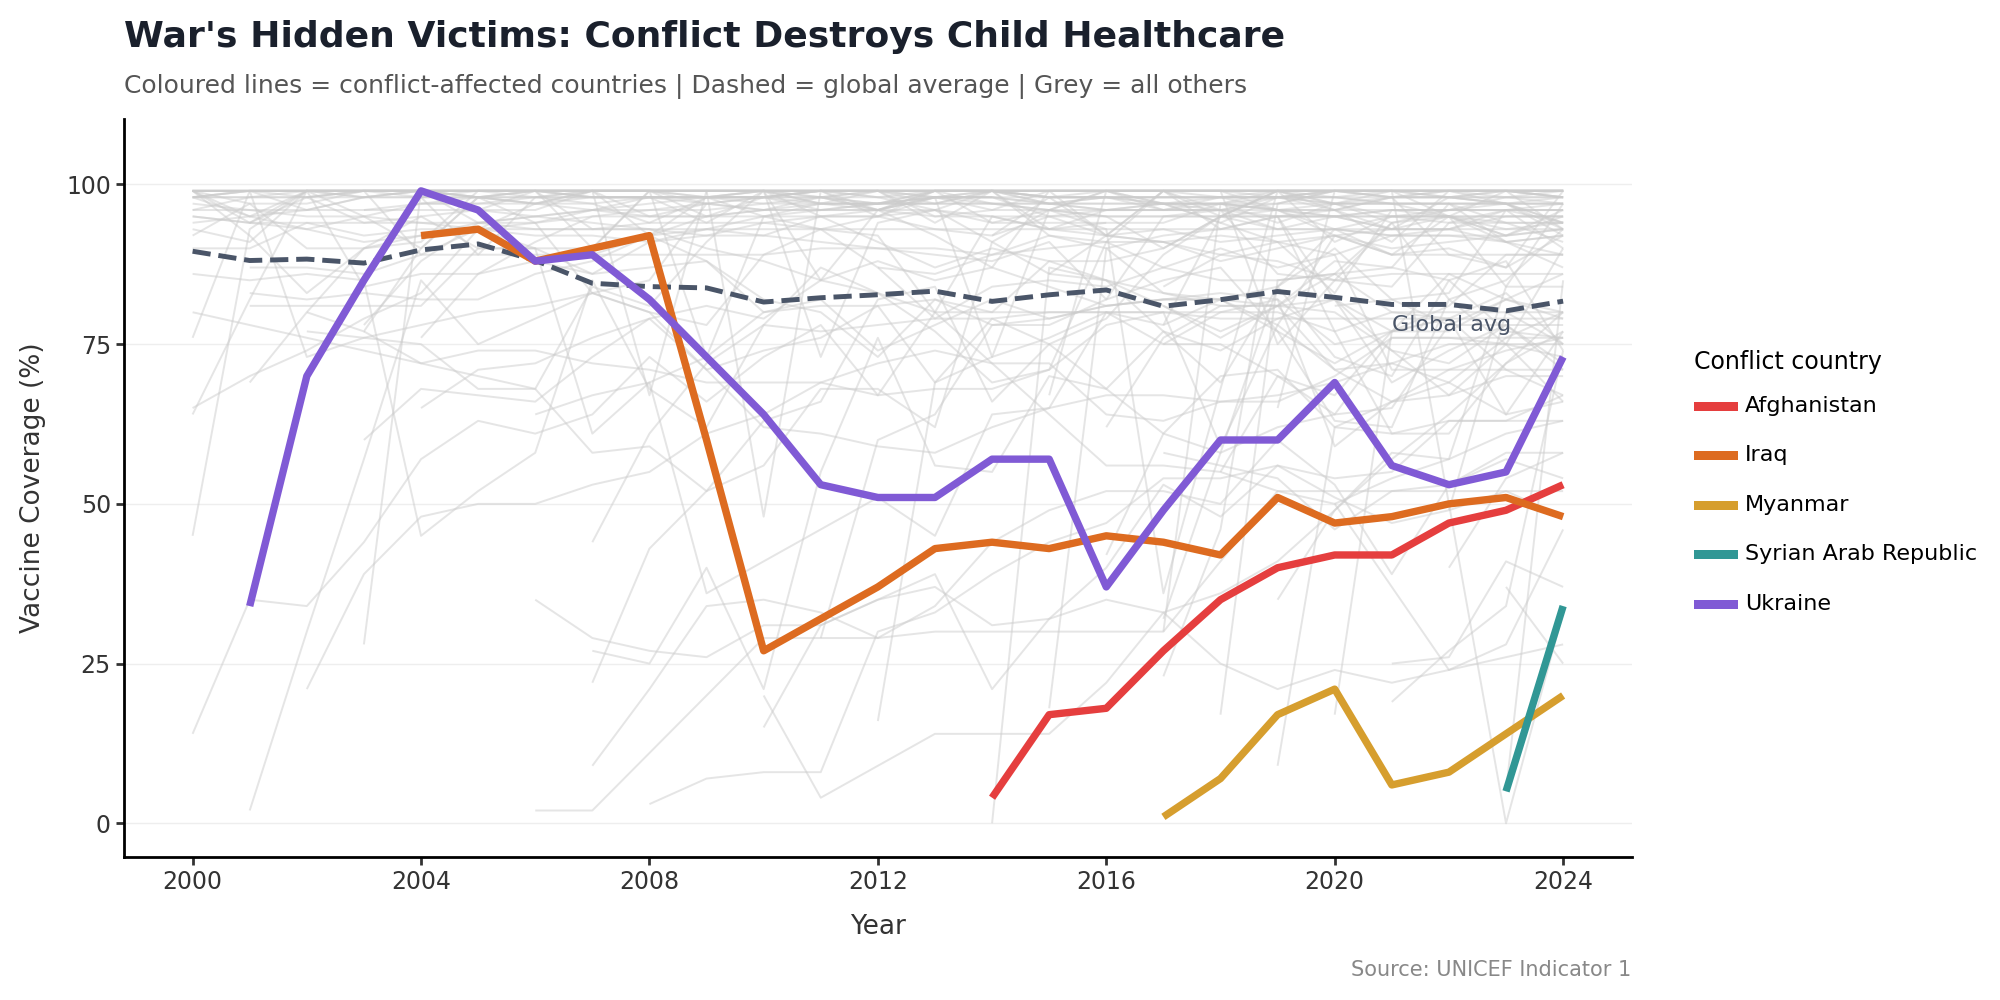

In [74]:
#| label: pn-conflict-ts
#| warning: false
#| fig-width: 10
#| fig-height: 5
#| fig-cap: "Hep-B vaccination coverage over time. Conflict countries highlighted in colour."

conflict_countries = ["Afghanistan","Iraq","Syrian Arab Republic","Myanmar","Ukraine"]
conflict_colors    = {
    "Afghanistan":"#e53e3e", "Iraq":"#dd6b20",
    "Myanmar":"#d69e2e", "Ukraine":"#805ad5",
    "Syrian Arab Republic":"#319795"
}

all_ts = (
    ind1.filter(pl.col("sex")=="Total")
    .select(["country","time_period","obs_value"])
    .to_pandas()
)
all_ts["is_conflict"] = all_ts["country"].isin(conflict_countries)
all_ts["color_group"] = all_ts["country"].map(conflict_colors).fillna("#cccccc")
all_ts["alpha_val"]   = all_ts["is_conflict"].map({True: 1.0, False: 0.3})
all_ts["size_val"]    = all_ts["is_conflict"].map({True: 1.2, False: 0.4})
all_ts["group_label"] = all_ts.apply(
    lambda r: r["country"] if r["country"] in conflict_countries else "Other countries", axis=1
)

bg   = all_ts[~all_ts["is_conflict"]].copy()
conf = all_ts[all_ts["is_conflict"]].copy()

# Global average line
global_avg_ts = all_ts.groupby("time_period")["obs_value"].mean().reset_index()
global_avg_ts.columns = ["time_period", "avg"]

(
    ggplot()
    + geom_line(
        bg, aes(x="time_period", y="obs_value", group="country"),
        color="#cccccc", size=0.4, alpha=0.5
    )
    + geom_line(
        global_avg_ts, aes(x="time_period", y="avg"),
        color="#4a5568", size=1.0, linetype="dashed"
    )
    + geom_line(
        conf, aes(x="time_period", y="obs_value", color="country"),
        size=1.5
    )
    + scale_color_manual(
        values=conflict_colors,
        name="Conflict country"
    )
    + scale_x_continuous(breaks=list(range(2000, 2025, 4)), name="Year")
    + scale_y_continuous(limits=[0, 105], name="Vaccine Coverage (%)")
    + annotate("text", x=2021, y=78, label="Global avg", size=8, color="#4a5568", ha="left")
    + labs(
        title="War's Hidden Victims: Conflict Destroys Child Healthcare",
        subtitle="Coloured lines = conflict-affected countries | Dashed = global average | Grey = all others",
        caption="Source: UNICEF Indicator 1"
    )
    + theme_classic()
    + unicef_theme()
    + theme(
        panel_grid_major_y=element_line(color="#eeeeee", size=0.5),
        figure_size=(10, 5)
    )
)

Iraq's trajectory is the most dramatic in the dataset. Coverage was above 80% in 2004 and collapsed to under 30% within a decade of the 2003 invasion, a fall of more than 50 percentage points tied directly to the destruction of the public health infrastructure that delivered vaccines. Afghanistan, Myanmar, Syria, and Ukraine each show their own inflection points: sharp drops coinciding with escalating conflict, followed in some cases by partial recovery as international aid rebuilt delivery capacity. No other variable in this dataset produces drops of this speed and magnitude.

---

### Chart 2: Military Spending versus Vaccine Coverage

This scatterplot joins the Hepatitis-B coverage data with the World Bank metadata on military expenditure as a share of GDP. An inner join on country name was used so only countries present in both datasets are plotted, this retains comparability at the cost of dropping countries with incomplete metadata. Bubble size encodes population; colour encodes GDP per capita on a continuous gradient.

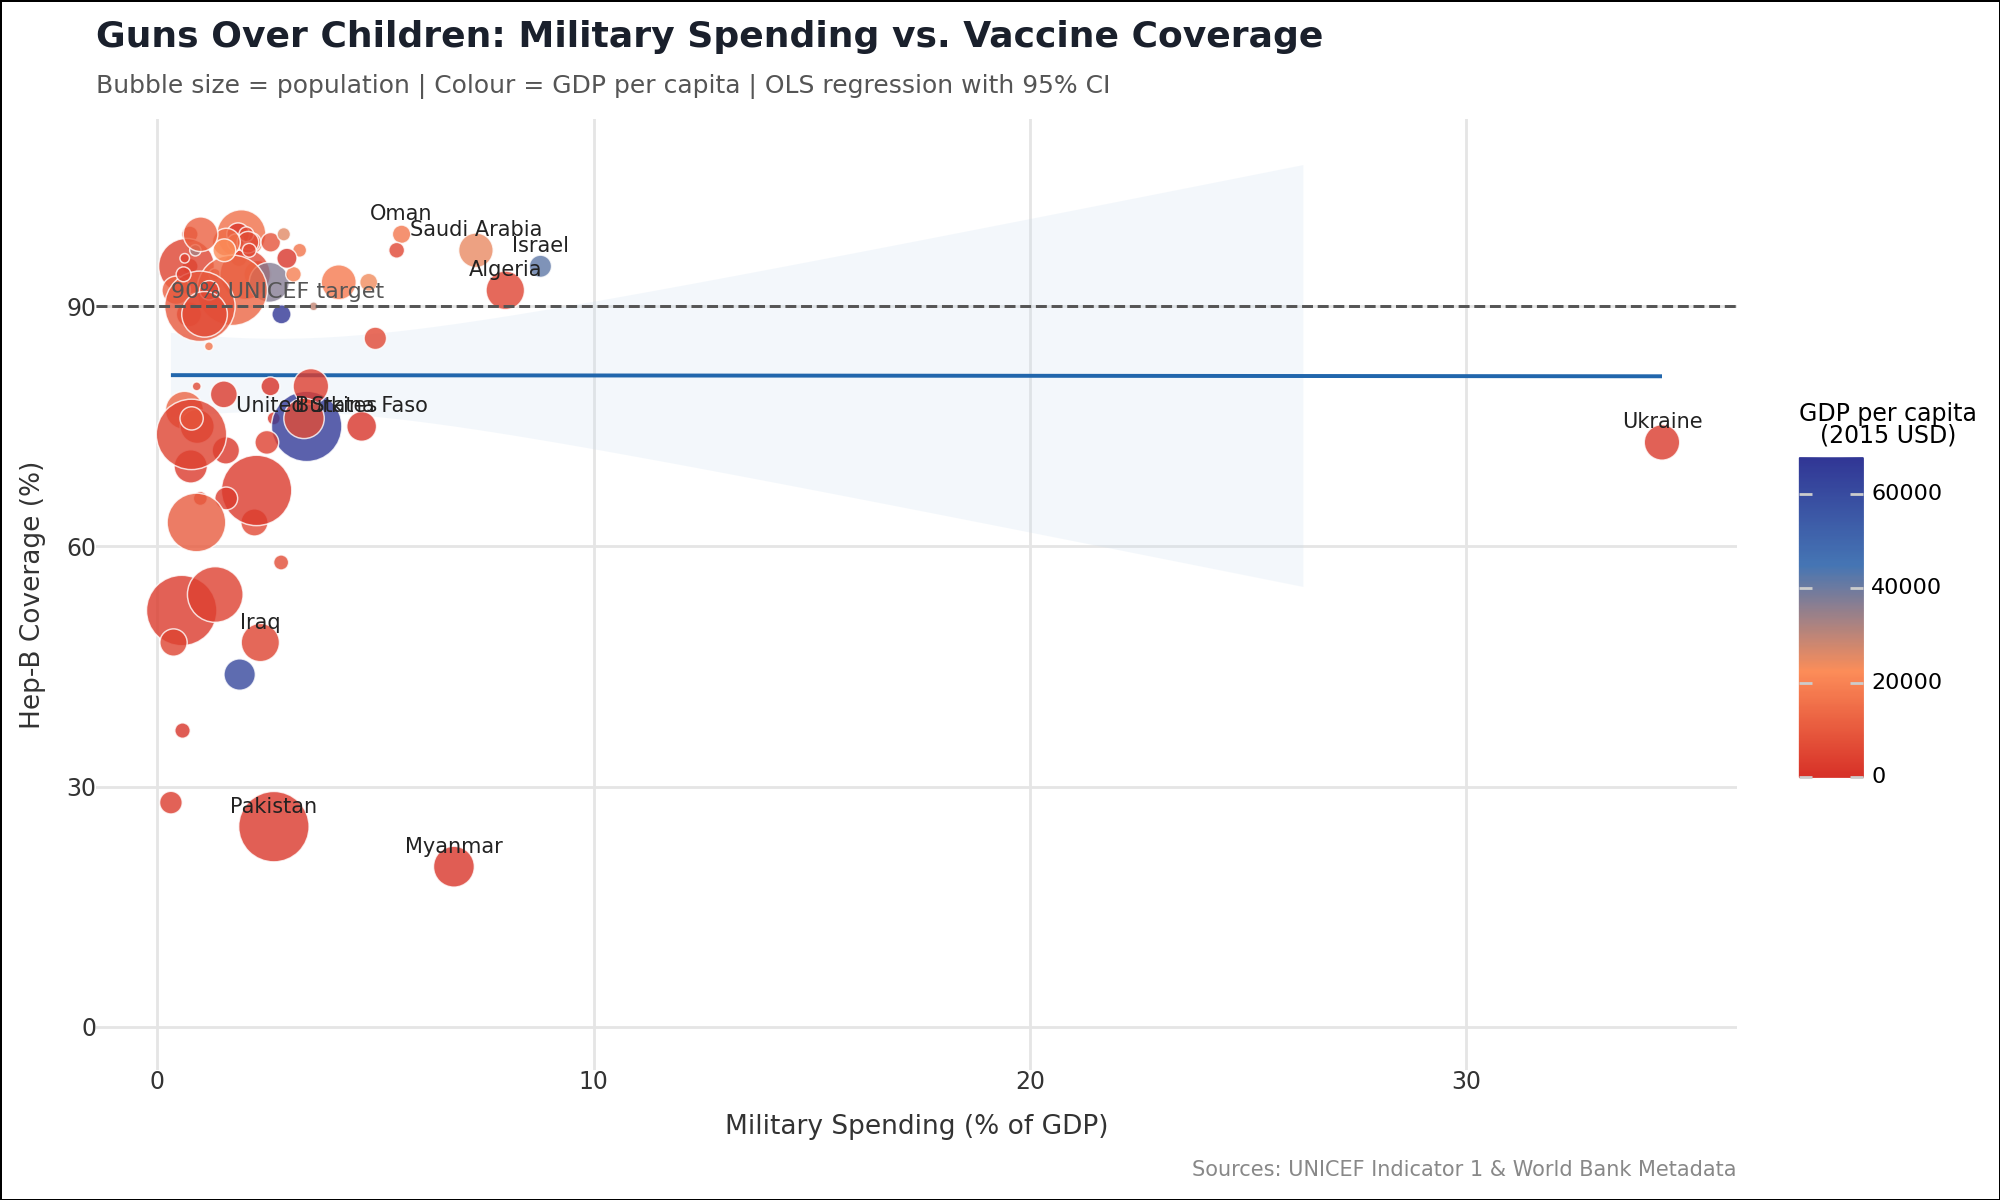

In [75]:
#| label: pn-military
#| warning: false
#| fig-width: 10
#| fig-height: 6
#| fig-cap: "Military expenditure (% of GDP) vs. Hep-B coverage (%). Bubble size = population. Colour = GDP per capita."

meta_latest = (
    meta.sort("year")
    .group_by("country")
    .agg([
        pl.col("Military expenditure (% of GDP)").last().alias("mil_pct"),
        pl.col("GDP per capita (constant 2015 US$)").last().alias("gdp_pc"),
        pl.col("Population, total").last().alias("population"),
    ])
)

mil_df = (
    hepb_pl.select(["country","hepb_pct"])
    .join(meta_latest, on="country", how="inner")
    .filter(pl.col("mil_pct").is_not_null() & pl.col("hepb_pct").is_not_null())
    .with_columns([
        (pl.col("population")/1_000_000).clip(lower_bound=0.5, upper_bound=200).alias("pop_m"),
        pl.col("gdp_pc").fill_null(0)
    ])
    .to_pandas()
)

label_countries = [
    "United States","Ukraine","Algeria","Iraq","Saudi Arabia",
    "Pakistan","Myanmar","Cuba","Israel","Oman","Burkina Faso","Viet Nam"
]
mil_df["label"] = mil_df["country"].apply(lambda c: c if c in label_countries else "")

(
    ggplot(mil_df, aes(x="mil_pct", y="hepb_pct"))
    + geom_smooth(method="lm", color="#2166ac", fill="#c6dbef", alpha=0.2, size=0.8)
    + geom_point(aes(size="pop_m", fill="gdp_pc"), shape="o", color="white", stroke=0.3, alpha=0.8)
    + geom_text(
        mil_df[mil_df["label"] != ""],
        aes(label="label"), size=7.5, color="#222222",
        nudge_y=2.5, ha="center"
    )
    + scale_fill_gradientn(
        colors=["#d73027","#fc8d59","#4575b4","#313695"],
        name="GDP per capita\n(2015 USD)"
    )
    + geom_hline(yintercept=90, linetype="dashed", color="#555", size=0.6)
    + annotate("text", x=0.3, y=91.8, label="90% UNICEF target", size=8, color="#555", ha="left")
    + scale_size_continuous(range=[1.5, 14], name="Population (M)", guide=None)
    + scale_x_continuous(name="Military Spending (% of GDP)")
    + scale_y_continuous(limits=[0, 108], name="Hep-B Coverage (%)")
    + labs(
        title="Guns Over Children: Military Spending vs. Vaccine Coverage",
        subtitle="Bubble size = population | Colour = GDP per capita | OLS regression with 95% CI",
        caption="Sources: UNICEF Indicator 1 & World Bank Metadata"
    )
    + theme_minimal()
    + unicef_theme()
    + theme(figure_size=(10, 6))
)

Several of the highest military spenders, Algeria, Oman, Saudi Arabia, and Pakistan all appear above 3% of GDP, cluster below the 90% target line. The OLS regression confirms a negative relationship: countries that spend more on their militaries tend to vaccinate fewer newborns. The relationship is not perfectly clean. Cuba is a notable outlier, achieving near universal coverage despite significant military expenditure but the direction is consistent and the 95% confidence interval does not cross zero across most of the spending range.

---

### Chart 3: Attendance versus Vaccination Gap

This diverging bar chart joins Indicator 1 and Indicator 2 on country name using an inner join, then computes the simple difference: school attendance rate minus Hepatitis-B coverage rate. Countries are sorted by this gap so the chart reads as a spectrum from most-vaccinated-relative-to-educated at the bottom to most-educated-relative-to-vaccinated at the top.

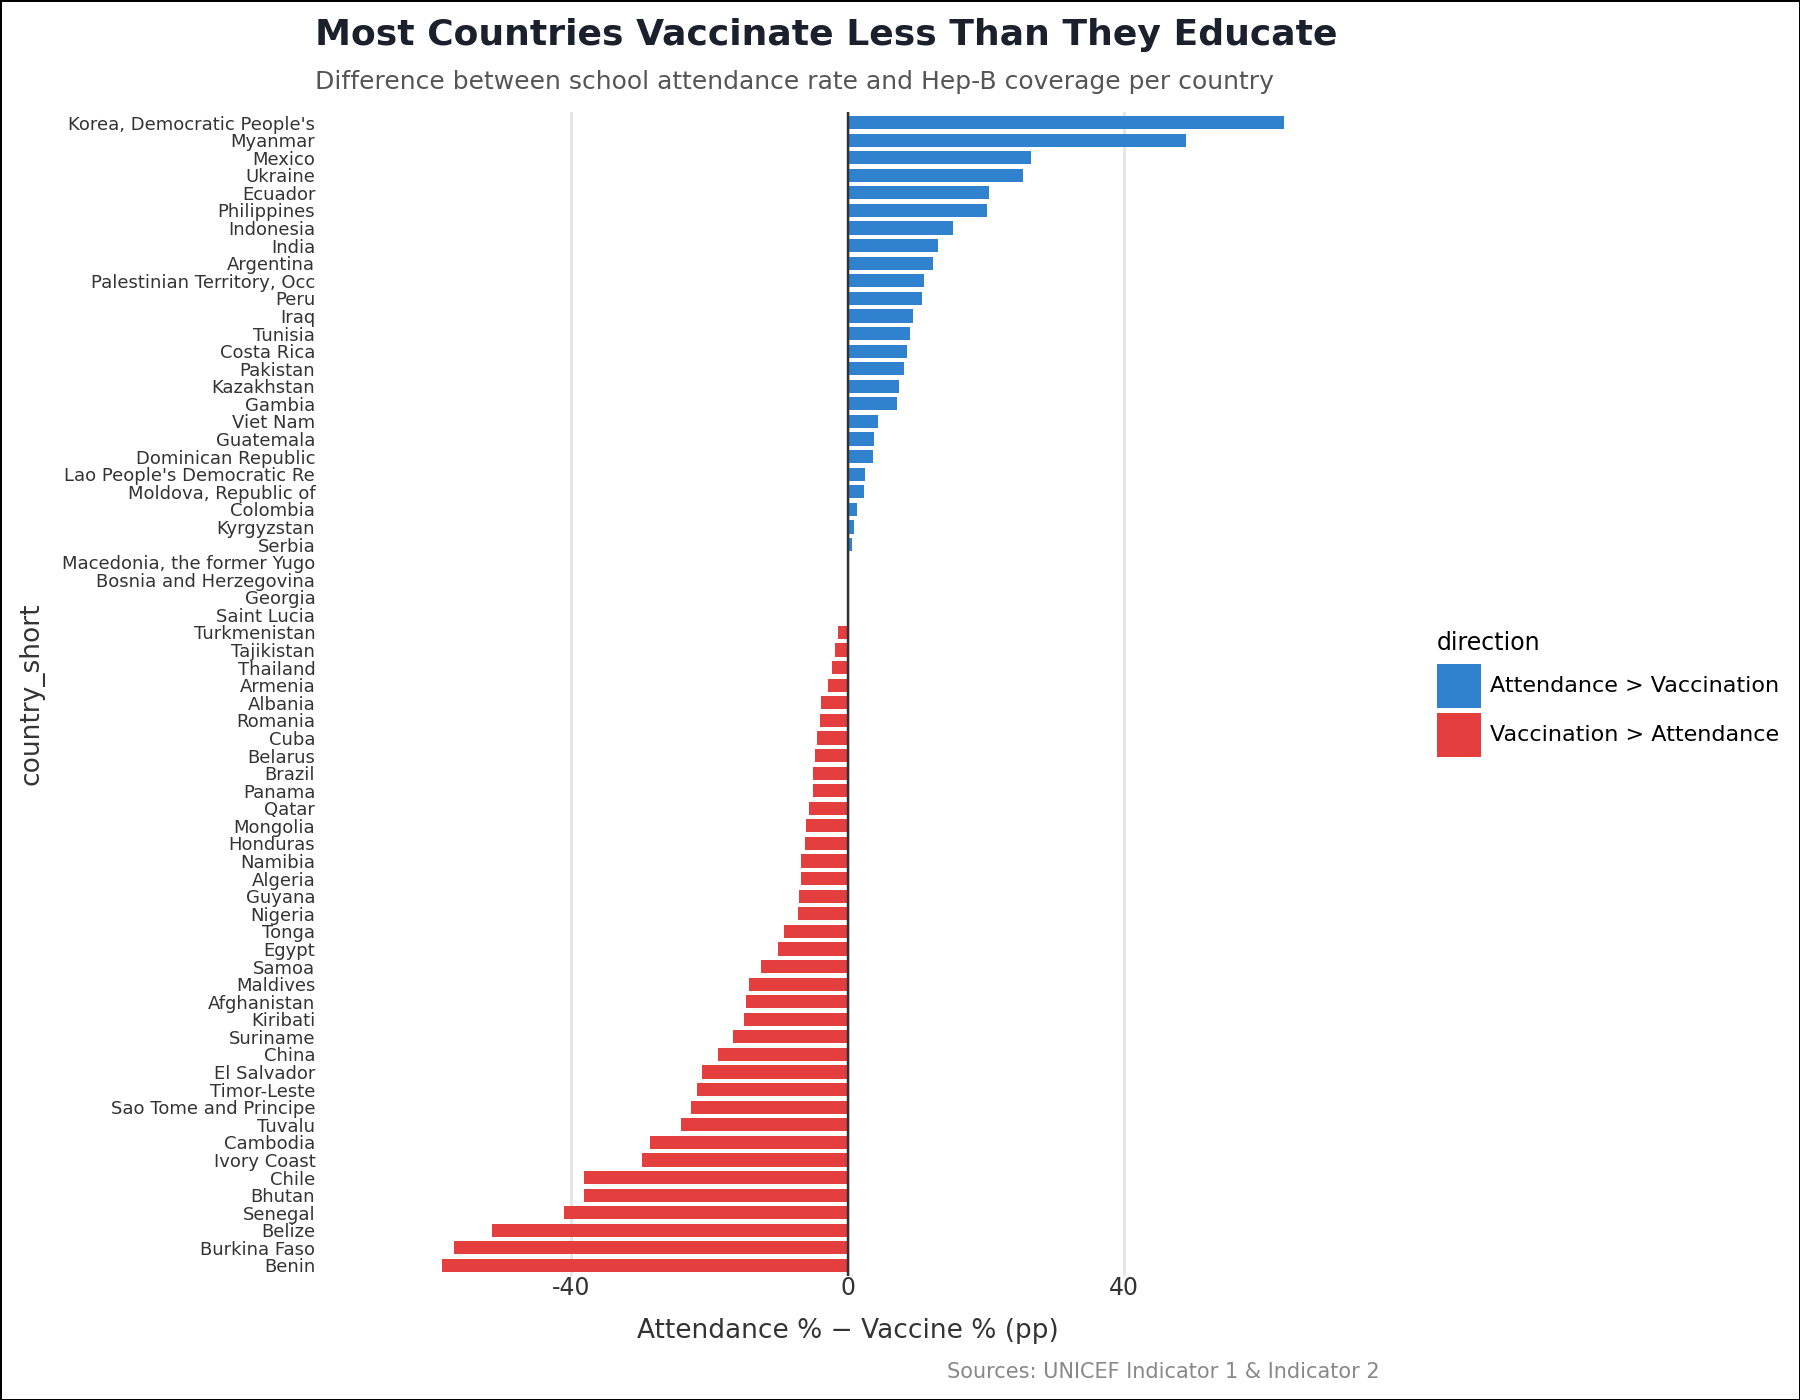

In [76]:
#| label: pn-diverging
#| warning: false
#| fig-width: 9
#| fig-height: 7
#| fig-cap: "Attendance rate minus Hep-B coverage (pp). Blue = attendance exceeds vaccination. Red = reverse."

div_df = (
    hepb_pl.select(["country","hepb_pct"])
    .join(att_pl.select(["country","att_pct"]), on="country", how="inner")
    .with_columns((pl.col("att_pct") - pl.col("hepb_pct")).alias("diff"))
    .filter(pl.col("diff").is_not_null())
    .sort("diff")
    .to_pandas()
)
div_df["direction"] = div_df["diff"].apply(
    lambda d: "Attendance > Vaccination" if d > 0 else "Vaccination > Attendance"
)
div_df["country_short"] = div_df["country"].str[:26]
# Order factor
import pandas as pd
div_df["country_short"] = pd.Categorical(
    div_df["country_short"],
    categories=div_df.sort_values("diff")["country_short"].tolist(),
    ordered=True
)

(
    ggplot(div_df, aes(x="country_short", y="diff", fill="direction"))
    + geom_col(width=0.75)
    + geom_hline(yintercept=0, color="#333333", size=0.5)
    + scale_fill_manual(
        values={"Attendance > Vaccination": "#3182ce",
                "Vaccination > Attendance": "#e53e3e"},
        name=""
    )
    + coord_flip()
    + scale_y_continuous(limits=[-70, 70], name="Attendance % − Vaccine % (pp)")
    + labs(
        x=None,
        title="Most Countries Vaccinate Less Than They Educate",
        subtitle="Difference between school attendance rate and Hep-B coverage per country",
        caption="Sources: UNICEF Indicator 1 & Indicator 2"
    )
    + theme_minimal()
    + unicef_theme()
    + theme(
        axis_text_y=element_text(size=6.5),
        panel_grid_major_y=element_blank(),
        figure_size=(9, 7)
    )
)

The diverging chart reveals a structural pattern that aggregates tend to hide. In the majority of countries with data for both indicators, school attendance exceeds Hepatitis-B coverage, often by 20 to 40 percentage points. This means children are reaching classrooms without ever having received birth-dose protection. The vaccine window is the first 24 hours of life; the school attendance window is years later. Missing the earlier opportunity cannot be undone by reaching the later one.

---

## The Evidence

### Chart 4: Hepatitis-B Coverage Heatmap

The heatmap encodes 25 years of Hepatitis-B coverage for every country as a colour tile, with countries sorted from lowest mean coverage at the top to highest at the bottom. Grey cells are years with no recorded observation.

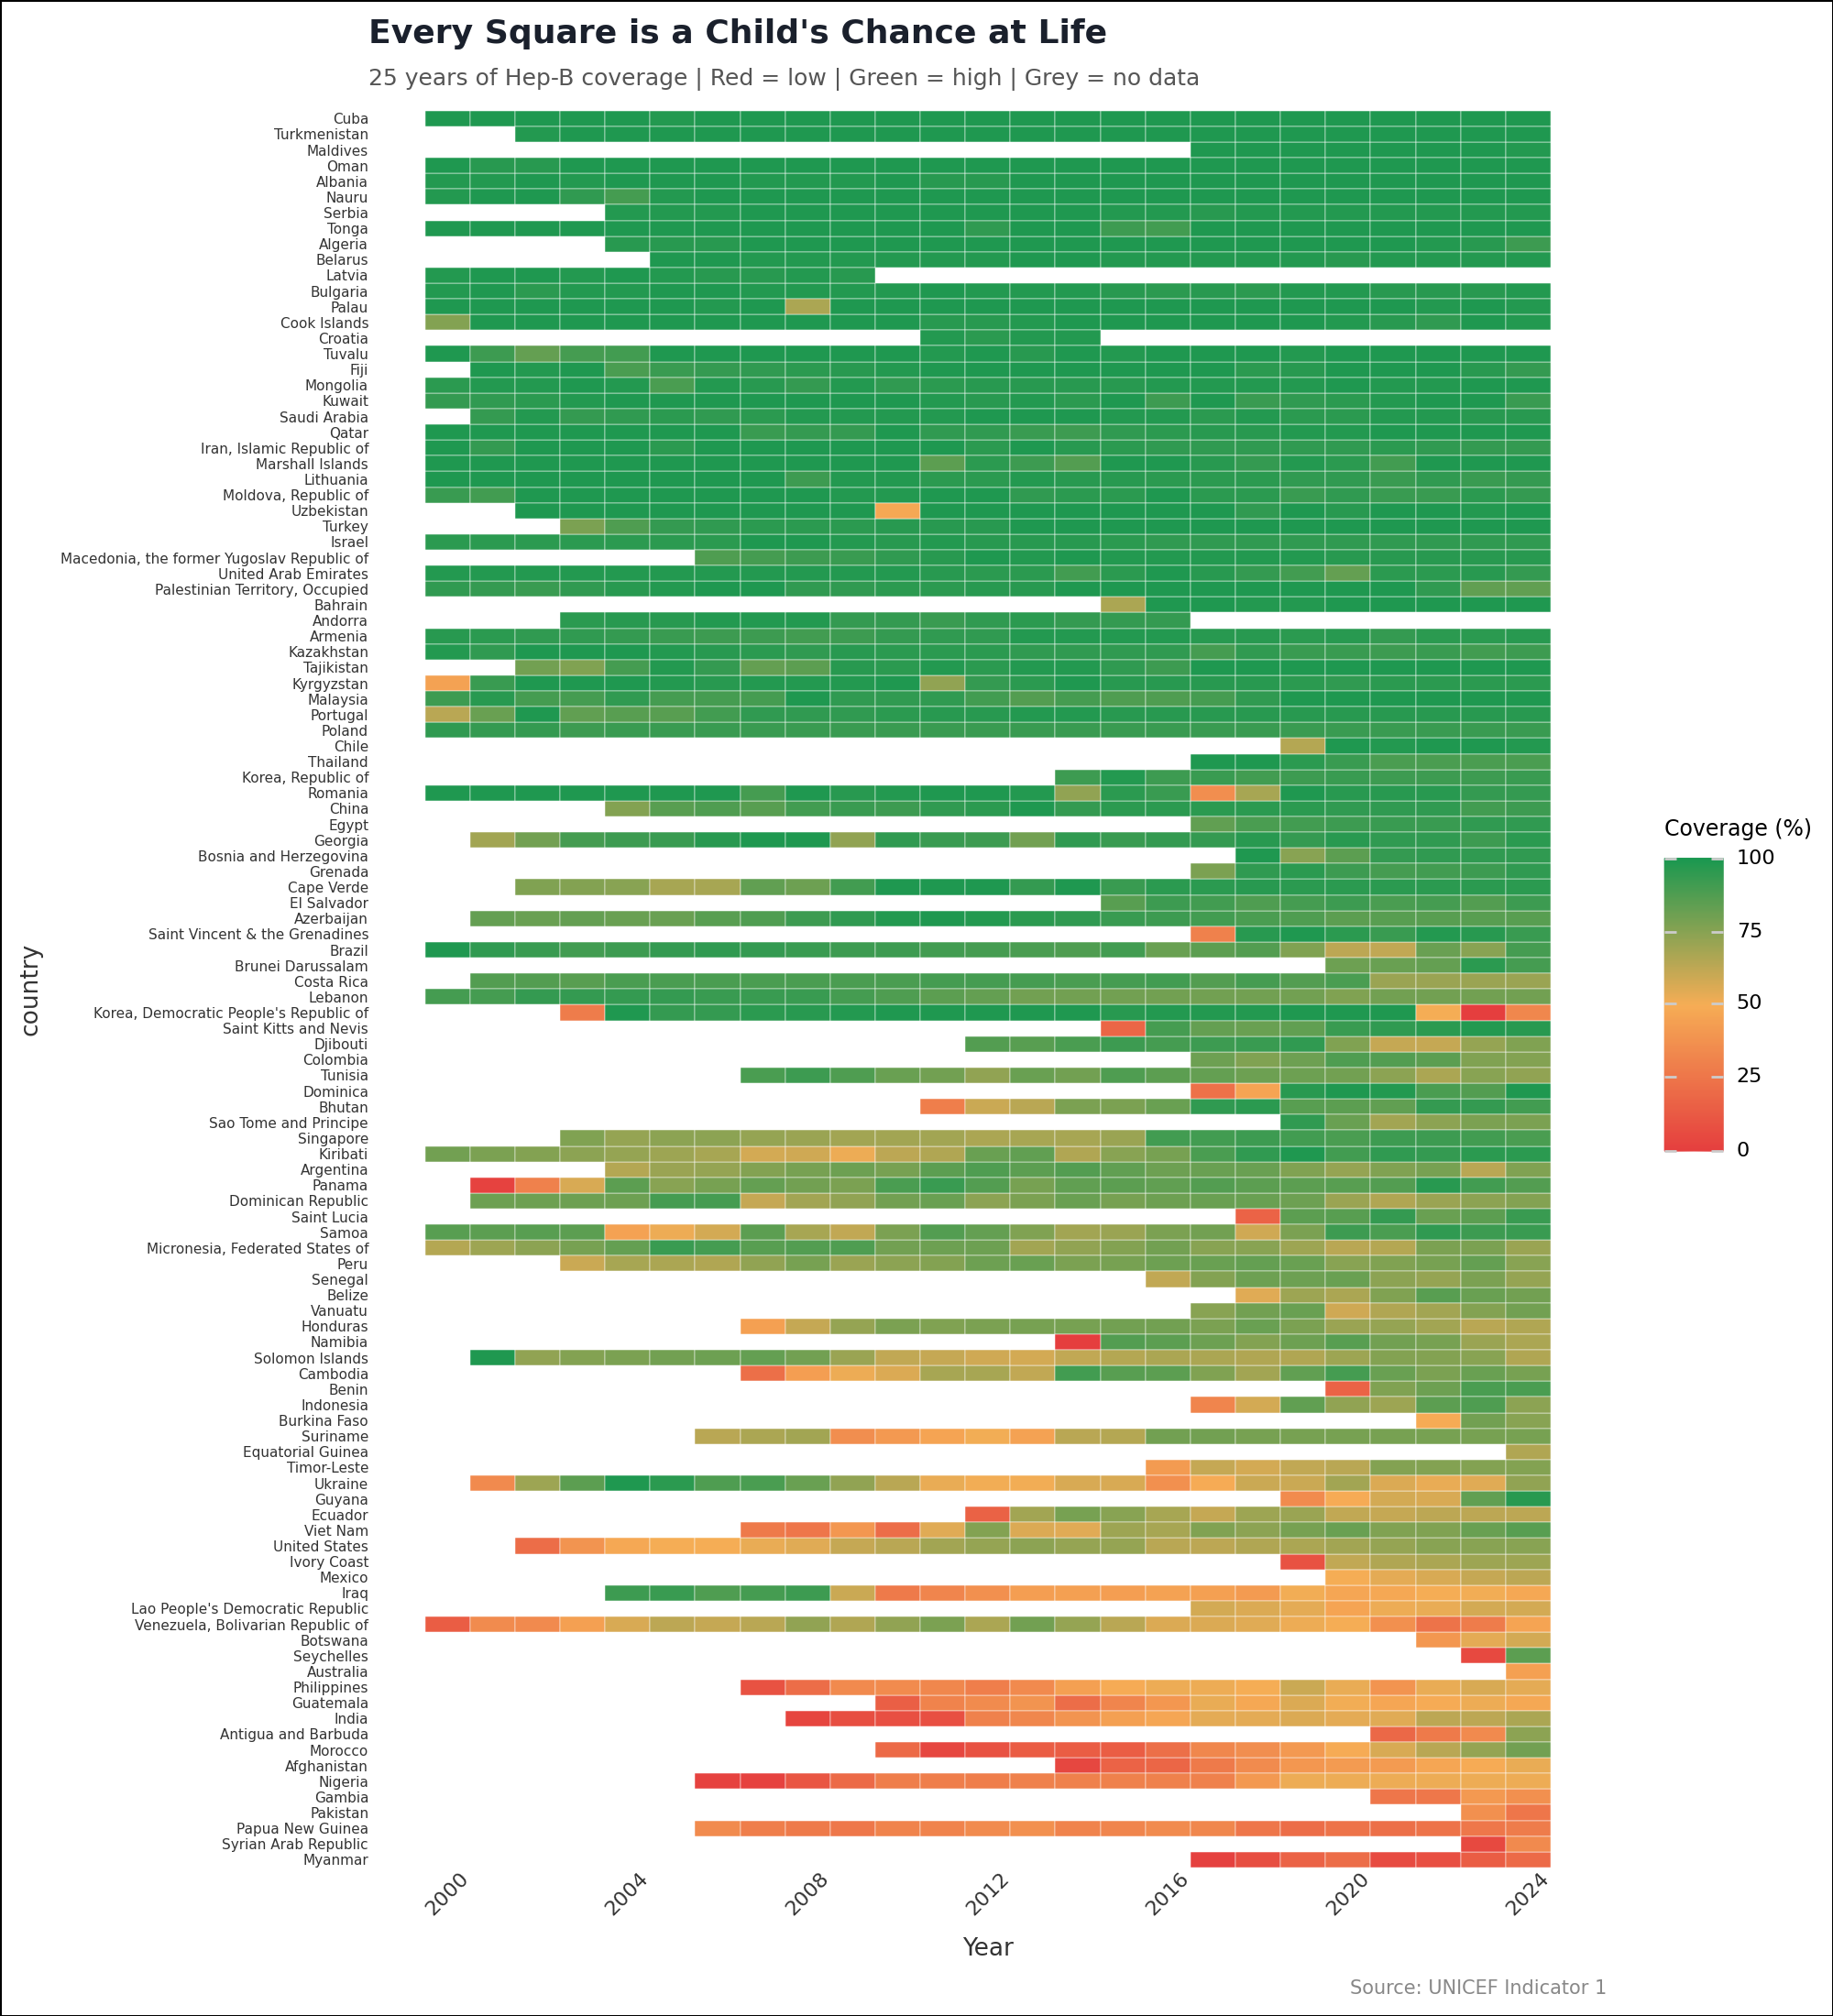

In [77]:
#| label: pn-heatmap
#| warning: false
#| fig-width: 10
#| fig-height: 11
#| fig-cap: "Hep-B coverage by country and year. Red = low, green = high, grey = no data."

heat_df = (
    ind1.filter(pl.col("sex")=="Total")
    .select(["country","time_period","obs_value"])
    .to_pandas()
)

# Sort countries by mean coverage (worst at top)
country_order = (
    heat_df.groupby("country")["obs_value"]
    .mean().sort_values(ascending=True).index.tolist()
)
heat_df["country"] = pd.Categorical(
    heat_df["country"], categories=country_order, ordered=True
)

(
    ggplot(heat_df, aes(x="time_period", y="country", fill="obs_value"))
    + geom_tile(color="white", size=0.1)
    + scale_fill_gradientn(
        colors=["#e53e3e","#f6ad55","#1a9850"],
        limits=[0, 100],
        na_value="#eeeeee",
        name="Coverage (%)"
    )
    + scale_x_continuous(breaks=list(range(2000,2025,4)), name="Year")
    + labs(
        y=None,
        title="Every Square is a Child's Chance at Life",
        subtitle="25 years of Hep-B coverage | Red = low | Green = high | Grey = no data",
        caption="Source: UNICEF Indicator 1"
    )
    + theme_minimal()
    + unicef_theme()
    + theme(
        axis_text_y=element_text(size=5.5),
        axis_text_x=element_text(size=8, angle=45),
        panel_grid=element_blank(),
        figure_size=(10, 11)
    )
)

The heatmap makes visible what country-level averages obscure. Several nations at the top of the chart show near-complete grey rows for entire decades, meaning UNICEF had no data for them at all, which is itself a measure of system fragility. Among countries with consistent data, the colour shift from red to green over time confirms that global coverage did improve between 2000 and roughly 2010, driven largely by the Gavi Alliance expansion. Since then, progress has stalled for a significant portion of the low-coverage cluster, and the COVID-19 disruption (2020 to 2021) is visible as a widespread lightening of colour across rows that had previously been trending green.

---

## Analytical Deep-Dive

### Chart 5: World Map: School Attendance Coverage

This plotnine world map uses a left join between the Natural Earth shapefile and the attendance data on ISO country codes, so every country geometry is retained and those without attendance data appear in grey. The fill gradient runs from red through amber to green on the same 0 to 100 scale used throughout the report.

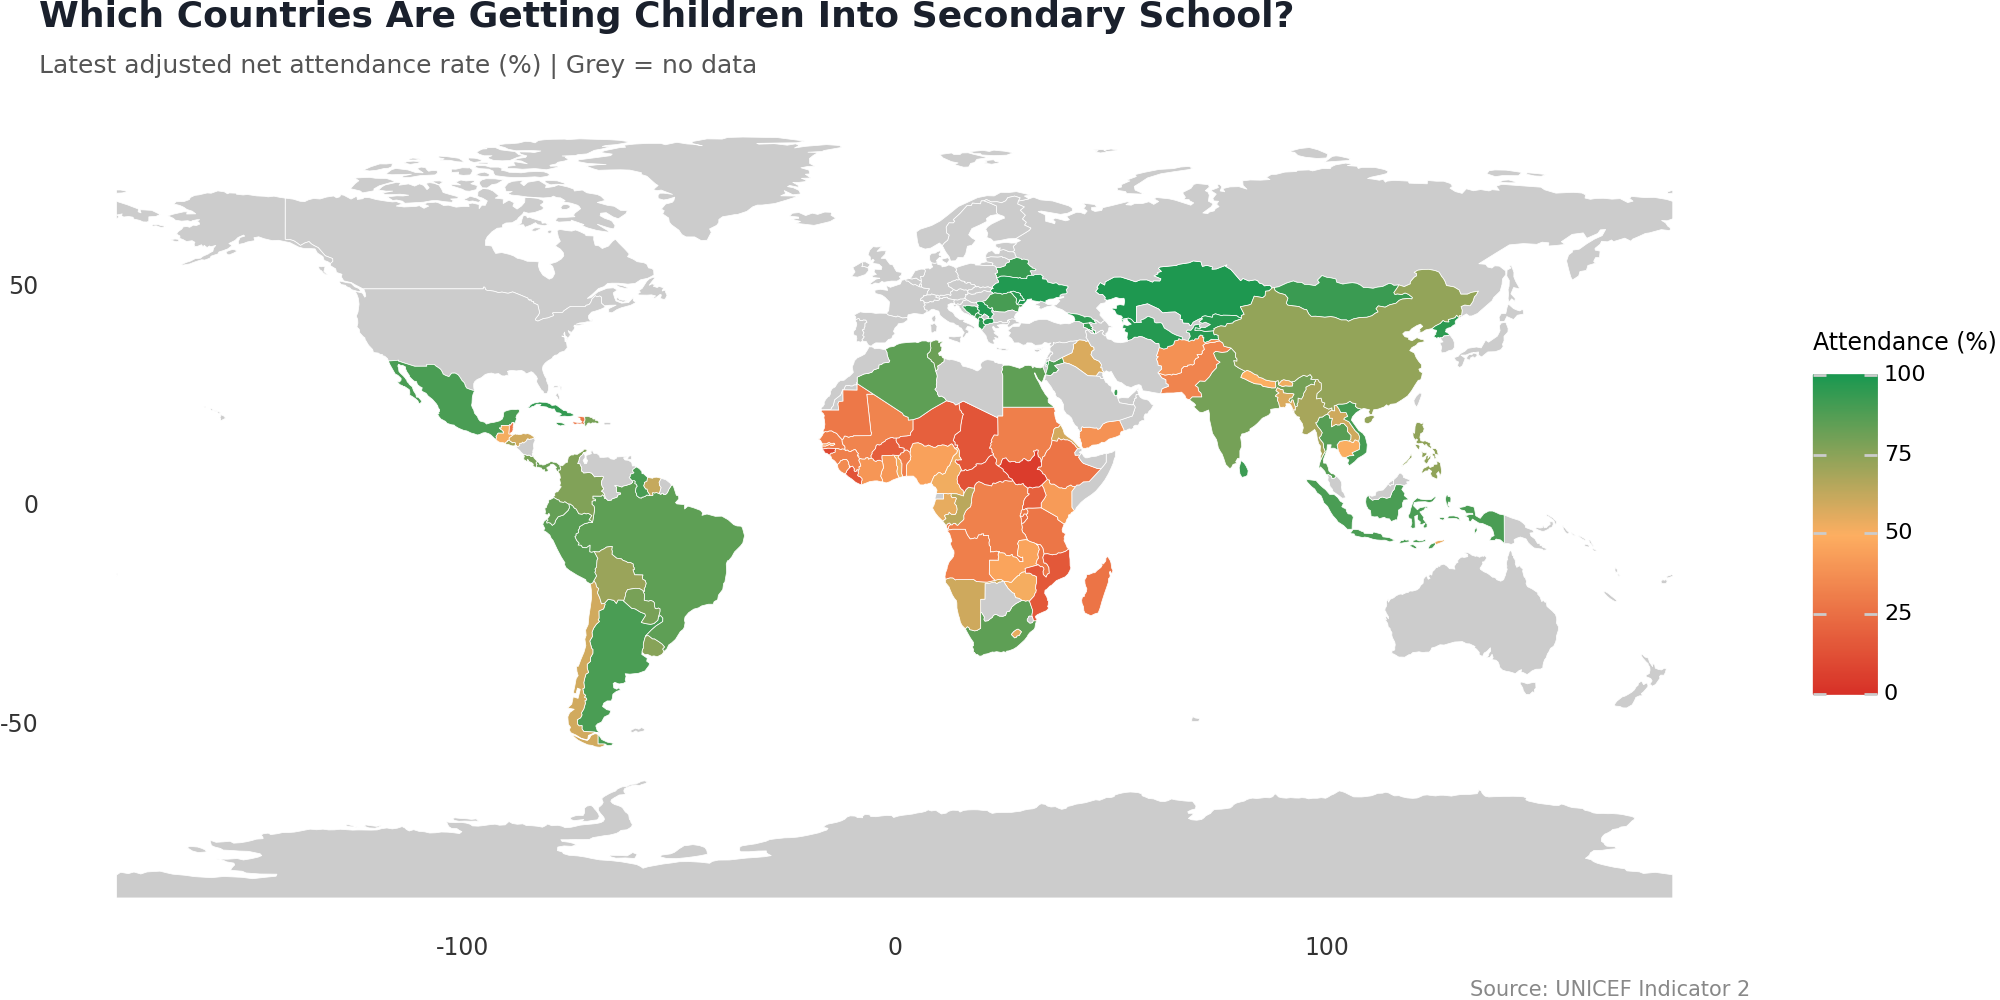

In [78]:
#| label: pn-world-map
#| warning: false
#| fig-width: 10
#| fig-height: 5
#| fig-cap: "Latest adjusted net school attendance rate (%) by country."

world_geo  = gpd.read_file(f"{DATA_PATH}ne_110m_countries.zip")[["ISO_A3","NAME","geometry"]]
world_att  = world_geo.merge(att[["alpha_3_code","att_pct"]],
                             left_on="ISO_A3", right_on="alpha_3_code", how="left")

(
    ggplot(world_att)
    + geom_map(aes(fill="att_pct"), color="white", size=0.15)
    + scale_fill_gradientn(
        colors=["#d73027","#fdae61","#1a9850"],
        limits=[0,100], na_value="#cccccc", name="Attendance (%)"
    )
    + labs(
        title="Which Countries Are Getting Children Into Secondary School?",
        subtitle="Latest adjusted net attendance rate (%) | Grey = no data",
        caption="Source: UNICEF Indicator 2"
    )
    + theme_void()
    + unicef_theme()
    + theme(figure_size=(10,5))
)

The attendance map complements the vaccination map from the opening section. Sub-Saharan Africa and South Asia show the lowest secondary attendance rates globally, closely mirroring the red zones in the Hepatitis-B coverage map. This geographic overlap is not coincidental, both failures share the same underlying causes: under-resourced health and education systems, high conflict exposure, and limited state capacity to deliver services at scale. Western and Central Europe, along with East Asia, appear consistently green on both maps.

### Chart 6: Gender Gap in School Attendance

The gender gap chart is built from a pivot of Indicator 2 on sex, retaining only the most recent Female and Male observations per country before computing the male-over-female difference. Only the top 12 countries by gap size are shown to keep the chart readable.

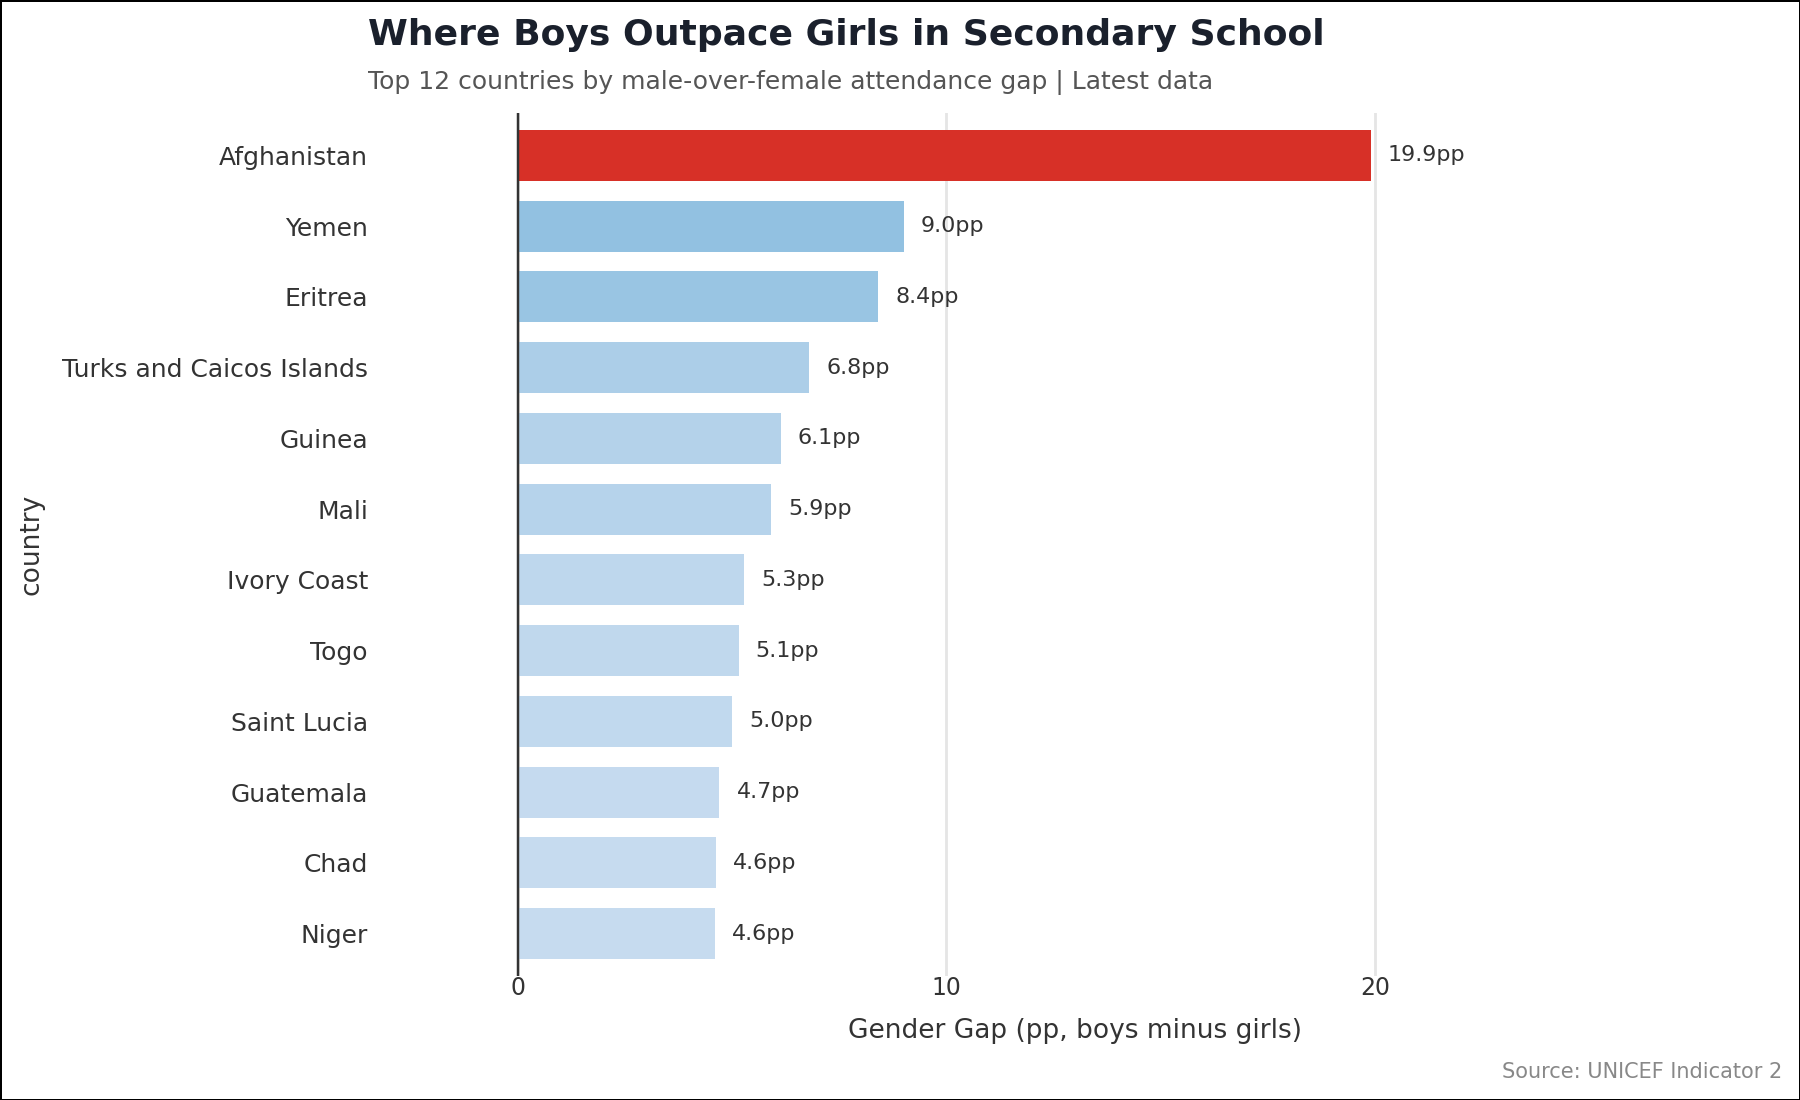

In [79]:
#| label: pn-gender-gap
#| warning: false
#| fig-width: 9
#| fig-height: 5.5
#| fig-cap: "Top 12 countries with the largest male-over-female gap in secondary school attendance."

school_gender = (
    ind2.filter(pl.col("sex").is_in(["Female","Male"]))
    .sort("time_period")
    .group_by(["country","sex"])
    .agg(pl.col("obs_value").last().alias("attendance"))
)
gap_df = (
    school_gender
    .pivot(on="sex", index="country", values="attendance")
    .with_columns((pl.col("Male")-pl.col("Female")).alias("gender_gap"))
    .filter(pl.col("gender_gap").is_not_null())
    .sort("gender_gap")
    .tail(12)
    .to_pandas()
)
gap_df["country"] = pd.Categorical(
    gap_df["country"],
    categories=gap_df.sort_values("gender_gap")["country"].tolist(),
    ordered=True
)
gap_df["gap_label"] = gap_df["gender_gap"].apply(lambda x: f"{x:.1f}pp")

(
    ggplot(gap_df, aes(x="country", y="gender_gap", fill="gender_gap"))
    + geom_col(width=0.72, show_legend=False)
    + geom_text(aes(label="gap_label"), ha="left", nudge_y=0.4, size=8, color="#333")
    + geom_hline(yintercept=0, color="#333", size=0.5)
    + scale_fill_gradientn(colors=["#c6dbef","#6baed6","#d73027"])
    + coord_flip()
    + scale_y_continuous(limits=[-2,28], name="Gender Gap (pp, boys minus girls)")
    + labs(
        x=None,
        title="Where Boys Outpace Girls in Secondary School",
        subtitle="Top 12 countries by male-over-female attendance gap | Latest data",
        caption="Source: UNICEF Indicator 2"
    )
    + theme_minimal()
    + unicef_theme()
    + theme(panel_grid_major_y=element_blank(), axis_text_y=element_text(size=9), figure_size=(9,5.5))
)

In the most extreme cases shown, boys attend secondary school at rates more than 20 percentage points higher than girls. These are not marginal gaps, they represent structural barriers that determine lifetime earnings, health literacy, and the likelihood that a mother will seek vaccination for her own newborn. The countries appearing here also tend to cluster in the lower half of the vaccination heatmap, suggesting that the same governance failures that exclude girls from school also fail to protect infants from preventable disease.

### Chart 7: Wealth and Vaccination Coverage

This scatterplot joins the Hepatitis-B coverage data with GDP per capita from the metadata file, filtering to countries where both values are non-null. GDP is plotted on a log10 scale because the relationship between income and health outcomes compresses at the high end. Bubble size encodes population to prevent large countries from visually disappearing.

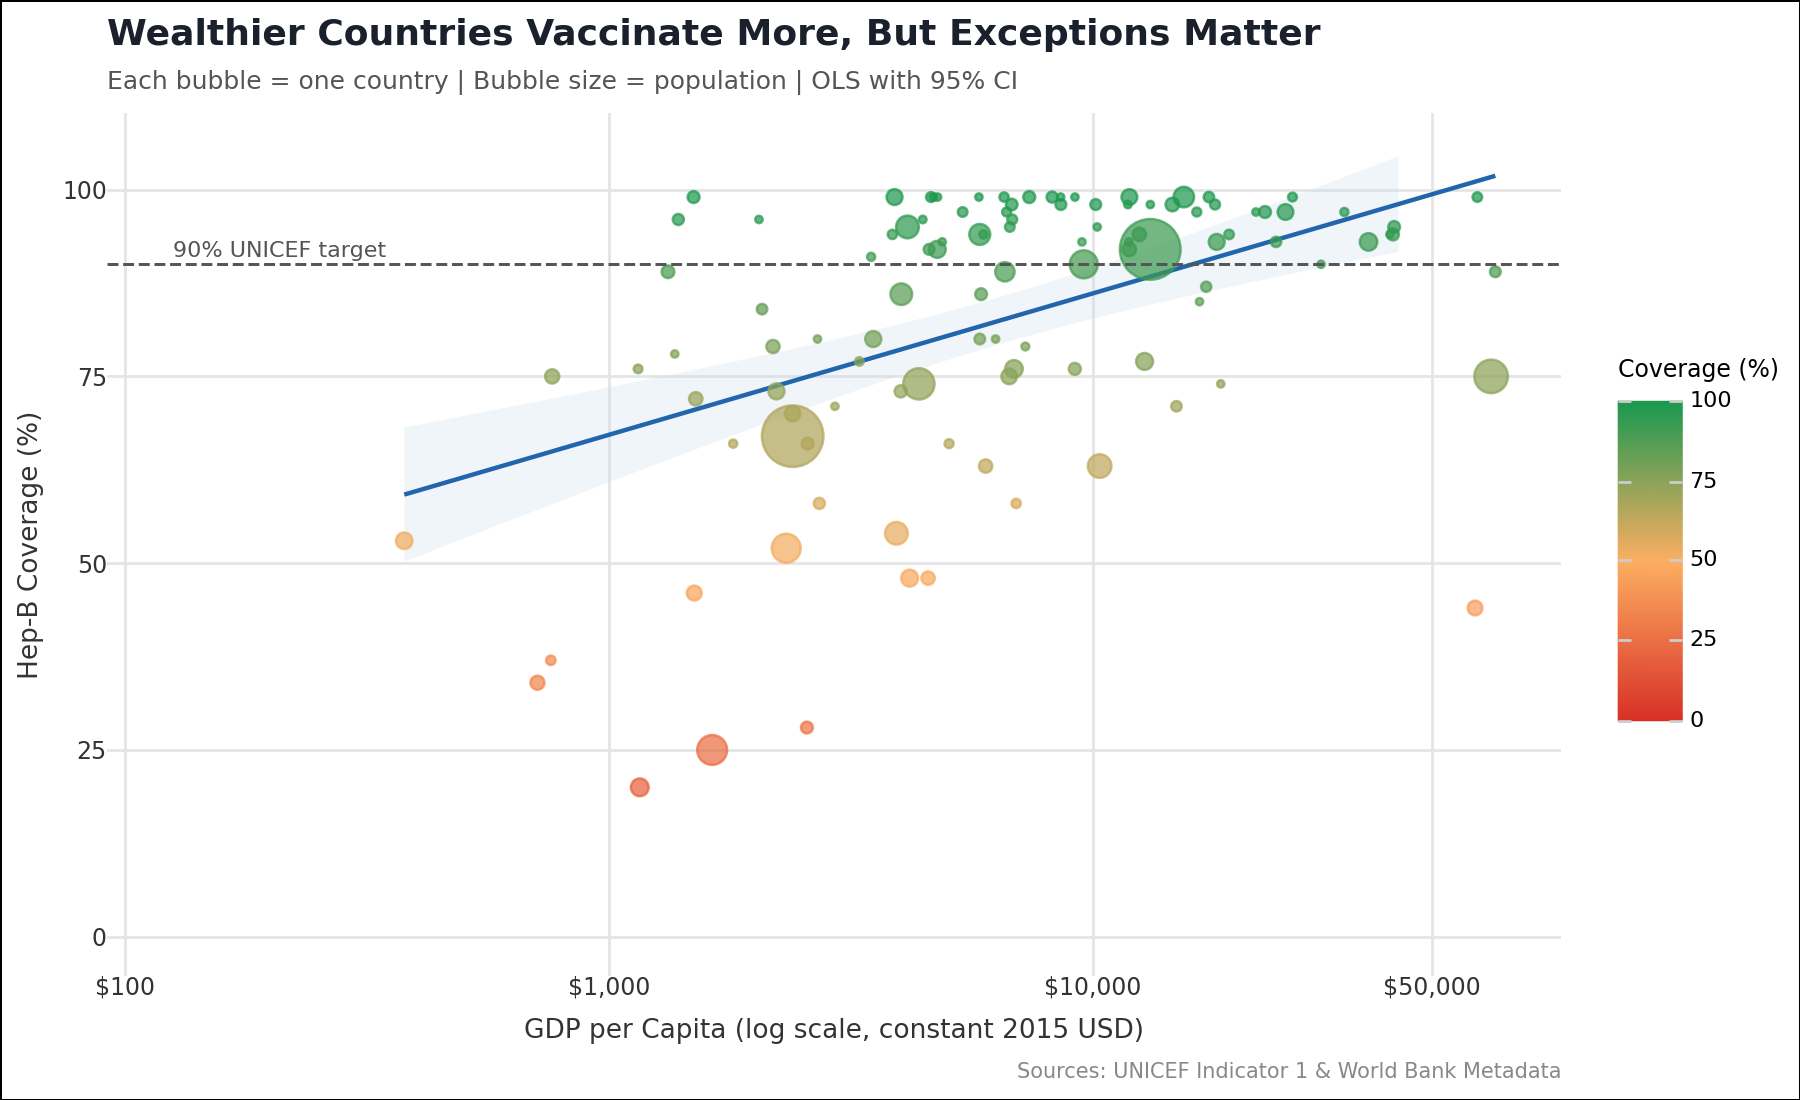

In [80]:
#| label: pn-scatter
#| warning: false
#| fig-width: 9
#| fig-height: 5.5
#| fig-cap: "Hepatitis-B coverage (%) vs. GDP per capita (log scale). Bubble size = population."

gdp_pl = (
    meta.filter(pl.col("GDP per capita (constant 2015 US$)").is_not_null())
    .sort("year")
    .group_by("country")
    .agg([
        pl.col("GDP per capita (constant 2015 US$)").last().alias("gdp_pc"),
        pl.col("Population, total").last().alias("population")
    ])
)
scat_df = (
    hepb_pl.select(["country","hepb_pct"])
    .join(gdp_pl, on="country", how="inner")
    .filter(pl.col("gdp_pc").is_not_null())
    .to_pandas()
)
scat_df["log_gdp"] = np.log10(scat_df["gdp_pc"])
scat_df["pop_m"]   = (scat_df["population"]/1_000_000).clip(lower=0.5)

(
    ggplot(scat_df, aes(x="log_gdp", y="hepb_pct"))
    + geom_smooth(method="lm", color="#2166ac", fill="#c6dbef", alpha=0.25, size=0.9)
    + geom_point(aes(size="pop_m", color="hepb_pct"), alpha=0.72)
    + scale_color_gradientn(colors=["#d73027","#fdae61","#1a9850"], limits=[0,100], name="Coverage (%)")
    + geom_hline(yintercept=90, linetype="dashed", color="#555", size=0.6)
    + annotate("text", x=2.1, y=91.8, label="90% UNICEF target", size=8, color="#555", ha="left")
    + scale_x_continuous(
        breaks=[2,3,4,4.7], labels=["$100","$1,000","$10,000","$50,000"],
        name="GDP per Capita (log scale, constant 2015 USD)"
    )
    + scale_y_continuous(limits=[0,105], name="Hep-B Coverage (%)")
    + scale_size_continuous(range=[1,12], name="Population (M)", guide=None)
    + labs(
        title="Wealthier Countries Vaccinate More, But Exceptions Matter",
        subtitle="Each bubble = one country | Bubble size = population | OLS with 95% CI",
        caption="Sources: UNICEF Indicator 1 & World Bank Metadata"
    )
    + theme_minimal()
    + unicef_theme()
    + theme(panel_grid_minor=element_blank(), figure_size=(9,5.5))
)

The positive relationship between GDP per capita and vaccination coverage holds broadly: richer countries do tend to vaccinate more of their newborns. But the scatter around the regression line tells the more important story. Several low-income countries have achieved coverage above 90% through strong primary healthcare investment, demonstrating that wealth is not the binding constraint. Conversely, a handful of upper-middle income countries sit well below the UNICEF target, suggesting that money alone does not guarantee good outcomes, political prioritisation matters independently of GDP.

### Chart 8: Global Hepatitis-B Coverage Over Time

The time series aggregates all country-year observations from Indicator 1, computing the global mean and one standard deviation band for each year. Annotations mark the Gavi Alliance expansion period and the COVID-19 disruption window.

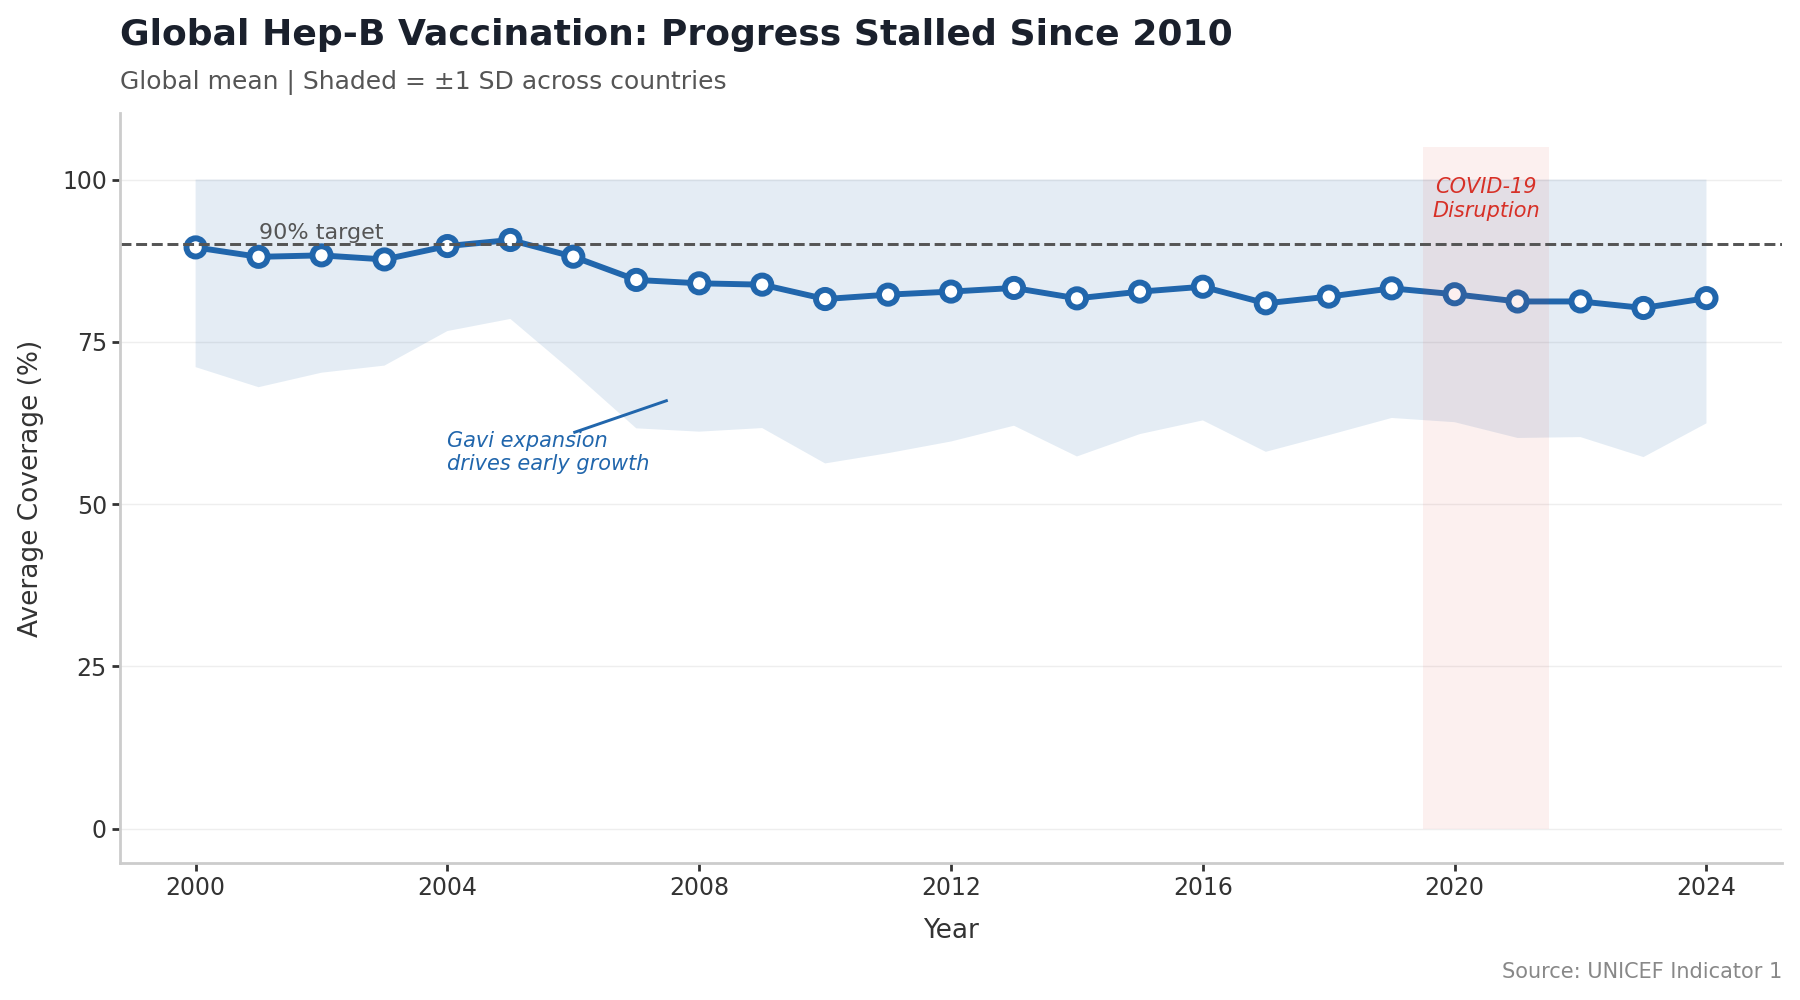

In [81]:
#| label: pn-timeseries
#| warning: false
#| fig-width: 9
#| fig-height: 5
#| fig-cap: "Global average Hep-B birth-dose coverage 2000–2024. Shaded band = ±1 SD."

ts_df = (
    ind1.filter(pl.col("sex")=="Total")
    .group_by("time_period")
    .agg([
        pl.col("obs_value").mean().alias("avg_hepb"),
        pl.col("obs_value").std().alias("sd_hepb")
    ])
    .sort("time_period")
    .with_columns([
        (pl.col("avg_hepb")+pl.col("sd_hepb")).clip(upper_bound=100).alias("upper"),
        (pl.col("avg_hepb")-pl.col("sd_hepb")).clip(lower_bound=0).alias("lower")
    ])
    .to_pandas()
)

(
    ggplot(ts_df, aes(x="time_period", y="avg_hepb"))
    + geom_ribbon(aes(ymin="lower", ymax="upper"), fill="#2166ac", alpha=0.12)
    + geom_line(color="#2166ac", size=1.2)
    + geom_point(color="#2166ac", size=2.5, fill="white", stroke=1.2)
    + annotate("rect", xmin=2019.5, xmax=2021.5, ymin=0, ymax=105, fill="#d73027", alpha=0.07)
    + annotate("text", x=2020.5, y=97, label="COVID-19\nDisruption", size=7.5, color="#d73027", ha="center", fontstyle="italic")
    + annotate("text", x=2004, y=58, label="Gavi expansion\ndrives early growth", size=7.5, color="#2166ac", ha="left", fontstyle="italic")
    + annotate("segment", x=2006, xend=2007.5, y=61, yend=66, color="#2166ac", size=0.6)
    + geom_hline(yintercept=90, linetype="dashed", color="#555", size=0.6)
    + annotate("text", x=2001, y=91.8, label="90% target", size=8, color="#555", ha="left")
    + scale_x_continuous(breaks=list(range(2000,2025,4)), name="Year")
    + scale_y_continuous(limits=[0,105], name="Average Coverage (%)")
    + labs(
        title="Global Hep-B Vaccination: Progress Stalled Since 2010",
        subtitle="Global mean | Shaded = ±1 SD across countries",
        caption="Source: UNICEF Indicator 1"
    )
    + theme_classic()
    + unicef_theme()
    + theme(
        panel_grid_major_y=element_line(color="#eeeeee", size=0.5),
        axis_line=element_line(color="#cccccc"),
        figure_size=(9,5)
    )
)

## What Must Change

Working through this data changed how I read a government budget. Every percentage point of GDP directed toward military spending is a percentage point not directed toward the health workers, cold-chain logistics, and rural clinics that get vaccines to newborns in their first 24 hours. The numbers are not abstract, they represent real decisions made by real governments, with consequences measured in the lives of children who never received a vaccine that costs less than a cup of coffee.

Three patterns emerged from the data that demand specific responses:

1. **Conflict is the fastest way to destroy a health system.** Iraq's coverage fell from above 80% in 2004 to below 30% within a decade of invasion. These are not gradual declines, they are sudden collapses tied to specific political events. Rebuilding takes years longer than the destruction.

2. **The gender gap in school attendance is not a cultural inevitability.** Several countries show boys attending secondary school at rates more than 20 percentage points higher than girls. These same countries cluster at the bottom of the vaccination heatmap, suggesting shared governance failures rather than isolated policy problems.

3. **Wealth helps but does not determine outcomes.** Some low-income countries have achieved over 90% coverage through deliberate health system investment, while some upper-middle income countries remain stuck below 60%. Political prioritisation matters independently of GDP.

In [82]:
#| label: closing-callout
#| echo: false
#| output: asis
display(HTML('''
<div style="background:linear-gradient(135deg,#fff5f5 0%,#ebf8ff 100%);border-left:5px solid #c53030;border-radius:8px;padding:20px 26px;margin:28px 0;">
<p style="color:#2d3748;font-style:italic;margin:0;line-height:1.7;">
The data in this report represents real children. The countries below 50% coverage are not statistics, they are places where, right now, a mother is leaving a clinic with a newborn who was not vaccinated, not because no vaccine exists, but because no one made sure it would be there. That is a policy failure. And policy failures can be fixed.
</p>
</div>
'''))


---

*Data source: UNICEF Open Data: unicef_indicator_1.csv, unicef_indicator_2.csv, unicef_metadata.csv*